In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    accuracy_score
)

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

X.head()

Features Shape: (569, 30)
Target Shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 455
Testing Samples: 114


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

print("Model Training Completed")

Model Training Completed


In [6]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [7]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.9737
Precision: 0.9722
Recall   : 0.9859
ROC-AUC  : 0.9974


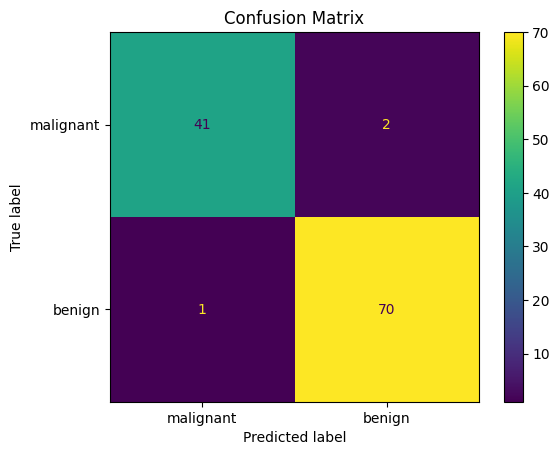

In [8]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

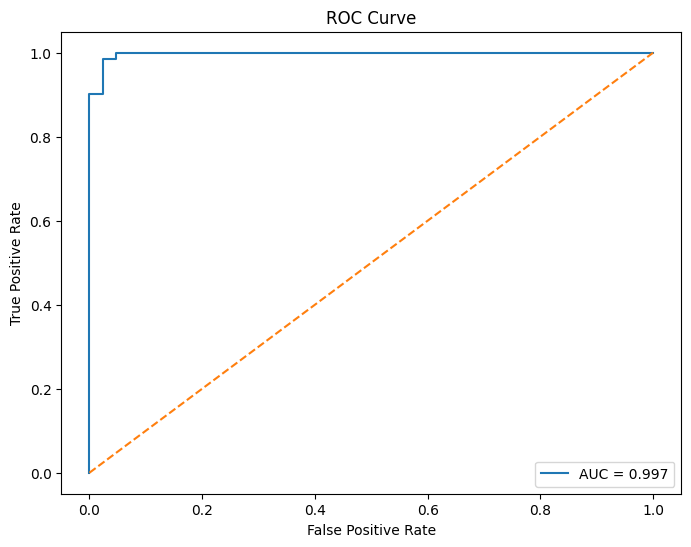

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [10]:
thresholds = [0.3, 0.5, 0.7]

for threshold in thresholds:
    predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)

    print(f"\nThreshold = {threshold}")
    print("Precision =", round(precision, 4))
    print("Recall    =", round(recall, 4))


Threshold = 0.3
Precision = 0.9726
Recall    = 1.0

Threshold = 0.5
Precision = 0.9722
Recall    = 0.9859

Threshold = 0.7
Precision = 0.9853
Recall    = 0.9437


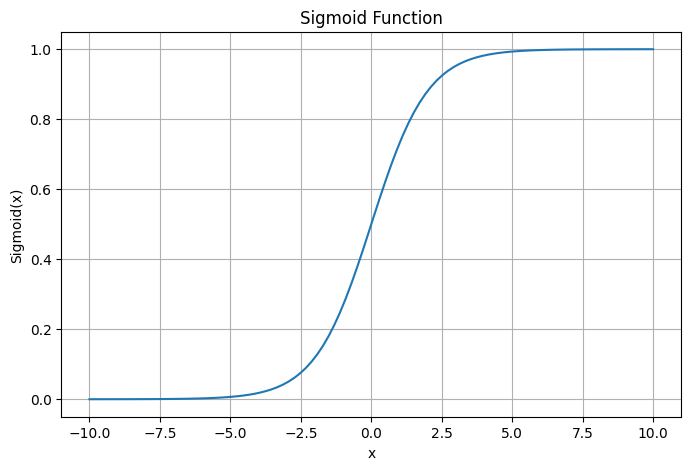

In [11]:
x = np.linspace(-10, 10, 100)

sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8,5))
plt.plot(x, sigmoid)
plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.grid(True)
plt.show()

In [14]:
print("=" * 60)
print("LOGISTIC REGRESSION FINAL REPORT")
print("=" * 60)

# Metrics
print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"ROC-AUC Score : {roc_auc:.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nDataset Information")
print(f"Total Samples    : {len(X)}")
print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")
print(f"Number of Features : {X.shape[1]}")

print("\nClass Distribution")
print(y.value_counts())

print("\nThreshold Tuning Results")
for threshold in [0.3, 0.5, 0.7]:
    pred = (y_prob >= threshold).astype(int)

    p = precision_score(y_test, pred)
    r = recall_score(y_test, pred)

    print(f"\nThreshold = {threshold}")
    print(f"Precision = {p:.4f}")
    print(f"Recall    = {r:.4f}")



LOGISTIC REGRESSION FINAL REPORT
Accuracy      : 0.9737
Precision     : 0.9853
Recall        : 0.9437
ROC-AUC Score : 0.9974

Confusion Matrix
[[41  2]
 [ 1 70]]

Dataset Information
Total Samples    : 569
Training Samples : 455
Testing Samples  : 114
Number of Features : 30

Class Distribution
1    357
0    212
Name: count, dtype: int64

Threshold Tuning Results

Threshold = 0.3
Precision = 0.9726
Recall    = 1.0000

Threshold = 0.5
Precision = 0.9722
Recall    = 0.9859

Threshold = 0.7
Precision = 0.9853
Recall    = 0.9437
